In [ ]:
from __future__ import annotations

import pathlib

import einops
import gpytorch.constraints
import lightning as L
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformertf.data.transform import (
    MinMaxScaler,
)
from transformertf.nn import MLP

from sa_preisach.nn import BinaryParameter
from sa_preisach.utils import (
    constant_mesh_size,
    create_triangle_mesh,
    get_states,
)

torch.set_num_threads(12)

In [2]:
CALIBRATION_FN_PATH = pathlib.Path(
    "~/cernbox/hysteresis/calibration_fn/SPS_MB_I2B_CALIBRATION_FN_v7.csv"
).expanduser()

TRAIN_DF_PATH = pathlib.Path(
    "~/cernbox/hysteresis/dipole/datasets/v6/MD20240904_all_drift_corrected_preprocessed.parquet"
).expanduser()
VAL_DF_PATH = pathlib.Path(
    "~/cernbox/hysteresis/dipole/datasets/v6/extras/SPS-BTRAIN-20231102-093421---20231102-094342_phys+lhcfill_md1_precycle_preprocessed.parquet"
).expanduser()

In [15]:
calibration_fn = np.loadtxt(CALIBRATION_FN_PATH, delimiter=",", skiprows=1)
xs = calibration_fn[:, 0]
ys = calibration_fn[:, 1]  # * 0.95

train_df = pd.read_parquet(TRAIN_DF_PATH)
val_df = pd.read_parquet(VAL_DF_PATH)

In [16]:
DOWNSAMPLE = 50

train_df = train_df.iloc[::DOWNSAMPLE, :].reset_index(drop=True)
val_df = val_df.iloc[::DOWNSAMPLE, :].reset_index(drop=True)

In [17]:
train_h = train_df["I_ref_A"].to_numpy()
train_b = train_df["B_meas_T"].to_numpy() - np.interp(train_h, xs, ys)
# train_b = train_b + 2e-5 * train_h

val_h = val_df["I_ref_A"].to_numpy()
val_b = val_df["B_meas_T"].to_numpy() - np.interp(val_h, xs, ys)
# val_b = val_b + 2e-5 * val_h

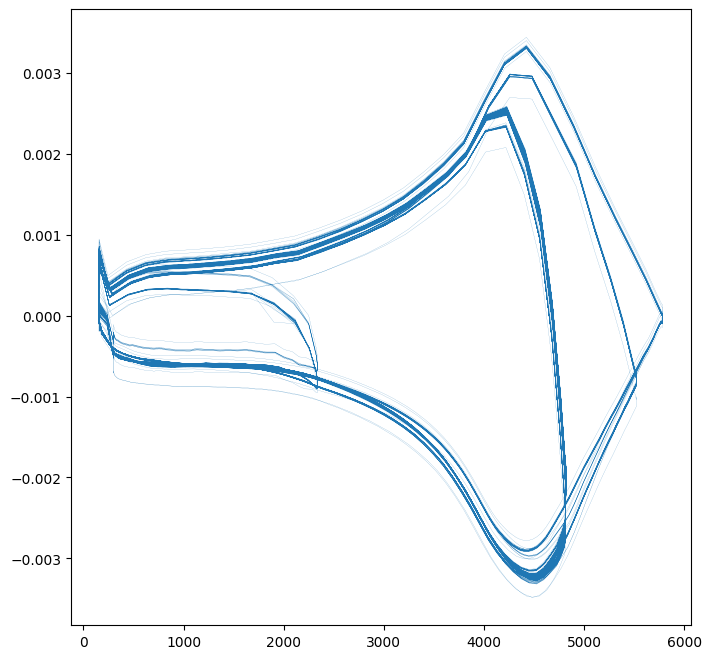

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.plot(train_h, train_b, label="train", linewidth=0.1)

In [19]:
h_scaler = MinMaxScaler(data_min_=100.0, data_max_=5800.0, frozen_=True)
h_scaler.fit(train_h)
h_train_norm = h_scaler.transform(train_h)
h_val_norm = h_scaler.transform(val_h)

b_scaler = MinMaxScaler(data_min_=-4e-3, data_max_=4e-3, frozen_=True)
b_scaler.fit(train_b)
b_train_norm = b_scaler.transform(train_b)
b_val_norm = b_scaler.transform(val_b)

The scaler is frozen and cannot be fitted.
The scaler is frozen and cannot be fitted.
The scaler is frozen and cannot be fitted.


In [20]:
mesh = create_triangle_mesh(
    0.1,
    constant_mesh_size,
)
alpha = torch.from_numpy(mesh[:, 1:2])
beta = torch.from_numpy(mesh[:, 0:1])

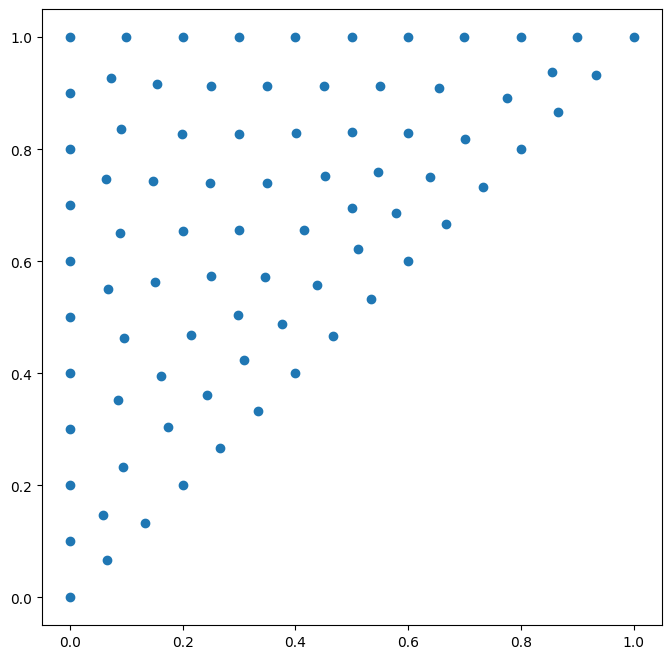

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.scatter(beta, alpha)

In [41]:
class ConstrainedParameter(torch.nn.Module):
    def __init__(
        self,
        data: torch.Tensor,
        min_: float = 0.0,
        max_: float = 1.0,
        eps: float = 1e-3,
        *,
        requires_grad: bool = True,
        **kwargs,
    ):
        super().__init__()
        self.min_ = min_
        self.max_ = max_

        self.constraint = gpytorch.constraints.Interval(min_, max_)

        self.raw_parameter = torch.nn.Parameter(
            self.inverse(data), requires_grad=requires_grad, **kwargs
        )

    def forward(self) -> torch.Tensor:
        return self.constraint.transform(self.raw_parameter)

    def inverse(self, x: torch.Tensor) -> torch.Tensor:
        # Map from [min_, max_] to [0,1]
        return self.constraint.inverse_transform(x)

    @property
    def data(self) -> torch.Tensor:
        return self.raw_parameter

    @property
    def value(self) -> torch.Tensor:
        return self.forward()

In [42]:
class DifferentiablePreisachModel(torch.nn.Module):
    def __init__(
        self,
        mesh_size: float,
        hidden_dim: int | tuple[int, ...] = (16, 16, 16),
        m_scale_bounds: tuple[float, float] = (0.0, 10.0),
        offset_bounds: tuple[float, float] = (-10.0, 10.0),
        h_slope_bounds: tuple[float, float] = (0.0, 10.0),
    ) -> None:
        super().__init__()

        mesh = create_triangle_mesh(
            mesh_size,
            constant_mesh_size,
        )

        # shift alpha and beta to be in the range (1e-2, 1 - 1e-2)
        mesh[:, 0] = mesh[:, 0] * 0.98 + 0.01
        mesh[:, 1] = mesh[:, 1] * 0.98 + 0.01

        self.alpha = ConstrainedParameter(
            torch.tensor(mesh[:, 1], requires_grad=True).float(),
        )
        self.beta = ConstrainedParameter(
            torch.tensor(mesh[:, 0], requires_grad=True).float(),
        )
        n_mesh_points = mesh.shape[0]

        self.density = torch.compile(
            MLP(
                input_dim=2,
                output_dim=1,
                hidden_dim=hidden_dim,
                activation="relu",
                dropout=0.0,
            )
        )

        self.m_scale = ConstrainedParameter(
            torch.tensor(1.0),
            min_=m_scale_bounds[0],
            max_=m_scale_bounds[1],
        )
        self.m_offset = ConstrainedParameter(
            torch.tensor(1.0),
            min_=offset_bounds[0],
            max_=offset_bounds[1],
        )
        self.h_scale = ConstrainedParameter(
            torch.tensor(1.0),
            min_=h_slope_bounds[0],
            max_=h_slope_bounds[1],
        )

        initial_state = torch.zeros((1, n_mesh_points), dtype=torch.float32)
        torch.nn.init.xavier_uniform_(initial_state.data)
        initial_state = initial_state.squeeze(0)

        self.initial_state = BinaryParameter(
            initial_state,
        )

    def forward(
        self, x: torch.Tensor, y0: torch.Tensor | float = 0.0, *, temp: float = 1e-3
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        states = get_states(
            x,
            self.alpha.value,
            self.beta.value,
            temp=temp,
            current_state=self.initial_state.value,
            current_field=y0,
            dtype=torch.float32,
            training=self.training,
        )

        density = self.density(self.mesh)
        density = torch.nn.functional.sigmoid(density)
        density = einops.rearrange(density, "n 1 -> 1 n")

        m = torch.sum(density * states, dim=-1) / torch.sum(density, dim=-1)

        return (
            self.m_scale.value * m + self.m_offset.value + self.h_scale.value * x,
            density,
            states,
        )

    @property
    def mesh(self) -> torch.Tensor:
        return torch.cat(
            [
                self.alpha.value.unsqueeze(-1),
                self.beta.value.unsqueeze(-1),
            ],
            dim=1,
        )


class DifferentiablePreisach(L.LightningModule):
    def __init__(
        self,
        mesh_size: float,
        *,
        hidden_dim: int | tuple[int, ...] = (16, 16, 16),
        temp: float = 1e-3,
        lr: float = 1e-2,
        lr_scale: float = 1e-3,
        lr_sa: float = 1e-2,
        gradient_clip: float = 1.0,
        m_scale_bounds: tuple[float, float] = (0.0, 10.0),
        offset_bounds: tuple[float, float] = (-10.0, 10.0),
        h_slope_bounds: tuple[float, float] = (0.0, 10.0),
        dist_threshold: float = 1e-3,
        compile_model: bool = True,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()

        self.model = DifferentiablePreisachModel(
            mesh_size=mesh_size,
            hidden_dim=hidden_dim,
            m_scale_bounds=m_scale_bounds,
            offset_bounds=offset_bounds,
            h_slope_bounds=h_slope_bounds,
        )

        self.loss_weights = torch.nn.Parameter(
            torch.tensor([1.0, 1.0, 1.0, 1.0]),
            requires_grad=True,
        )

        self.validation_outputs = list()
        self.automatic_optimization = False

    def on_fit_start(self) -> None:
        if self.hparams["compile_model"]:
            self.model = torch.compile(self.model)

        return super().on_fit_start()

    def on_validation_epoch_start(self):
        self.validation_outputs = list()
        return super().on_validation_epoch_start()

    def forward(
        self, x: torch.Tensor, y0: torch.Tensor | float = 0.0, *, temp: float = 1e-3
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.model(x, y0, temp=temp)

    def common_step(
        self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int
    ) -> dict[str, torch.Tensor]:
        x, y = batch
        x = x.squeeze(0)
        y = y.squeeze(0)
        y_hat, density, states = self(x, y0=y[0], temp=self.hparams["temp"])
        loss1 = torch.nn.functional.mse_loss(y_hat, y)
        loss2 = self.parameter_constraint_loss()
        loss3 = overlap_penalty_loss(
            self.model.mesh, min_dist=1e-6, constant=self.hparams["dist_threshold"] ** 2
        )
        loss4 = torch.abs(y_hat[0] - y[0])

        loss = sum(
            self.loss_weights[i] * loss
            for i, loss in enumerate([loss1, loss2, loss3, loss4])
        )

        return {
            "loss": loss,
            "loss_weights": self.loss_weights.detach().clone(),
            "loss1": loss1,
            "loss2": loss2,
            "loss3": loss3,
            "loss4": loss4,
            "y_hat": y_hat,
            "y": y,
            "x": x,
            "density": density.detach().clone(),
            "states": states.detach().clone(),
        }

    def training_step(
        self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int
    ) -> dict[str, torch.Tensor]:
        out = self.common_step(batch, batch_idx)
        loss = out["loss"]

        optimizer1, optimizer2, optimizer3 = self.optimizers()
        optimizer1.zero_grad()
        optimizer2.zero_grad()
        optimizer3.zero_grad()

        self.manual_backward(loss)

        self.clip_gradients(
            optimizer1,
            gradient_clip_val=self.hparams["gradient_clip"],
        )
        self.clip_gradients(
            optimizer2,
            gradient_clip_val=self.hparams["gradient_clip"],
        )

        optimizer1.step()
        optimizer2.step()

        for scheduler in self.lr_schedulers():
            self.lr_scheduler_step(scheduler, metric=None)

        self.negate_gradients()
        optimizer3.step()

        for tag, key in {
            "train/loss": "loss",
            "train/loss_mse": "loss1",
            "train/loss_alpha_geq_beta": "loss2",
            "train/loss_overlap": "loss3",
            "train/loss_i0": "loss4",
        }.items():
            self.log(tag, out[key], prog_bar=True, on_step=True, on_epoch=False)

        for tag, i in {
            "train/loss_weight_mse": 0,
            "train/loss_weight_alpha_geq_beta": 1,
            "train/loss_weight_overlap": 2,
            "train/loss_weight_i0": 3,
        }.items():
            self.log(
                tag, self.loss_weights[i], prog_bar=True, on_step=True, on_epoch=False
            )

        return out

    def validation_step(
        self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int
    ) -> dict[str, torch.Tensor]:
        with torch.no_grad():
            out = self.common_step(batch, batch_idx)

        for tag, key in {
            "validation/loss": "loss",
            "validation/loss_mse": "loss1",
        }.items():
            self.log(tag, out[key], prog_bar=True, on_step=False, on_epoch=True)

        self.validation_outputs.append(out)
        return out

    def parameter_constraint_loss(self) -> torch.Tensor:
        return torch.sum(
            torch.nn.functional.relu(self.model.beta.value - self.model.alpha.value)
        )

    def negate_gradients(self) -> None:
        for param in self.parameters():
            if param.grad is not None:
                param.grad = -param.grad

    def configure_optimizers(
        self,
    ) -> tuple[list[torch.optim.Optimizer], list[torch.optim.lr_scheduler.LRScheduler]]:
        optimizer1 = torch.optim.AdamW(
            [
                param
                for name, param in self.named_parameters()
                if name not in {"m_scale", "m_offset", "h_scale", "loss_weights"}
            ],
            lr=self.hparams["lr"],
            weight_decay=1e-4,
        )
        optimizer2 = torch.optim.AdamW(
            [
                self.model.m_scale.data,
                self.model.m_offset.data,
                self.model.h_scale.data,
            ],
            lr=self.hparams["lr_scale"],
            weight_decay=1e-4,
        )
        optimizer3 = torch.optim.SGD([self.loss_weights], lr=self.hparams["lr_sa"])
        scheduler1 = torch.optim.lr_scheduler.StepLR(
            optimizer1, step_size=200, gamma=0.9
        )
        scheduler2 = torch.optim.lr_scheduler.StepLR(
            optimizer2, step_size=200, gamma=0.9
        )
        return [optimizer1, optimizer2, optimizer3], [scheduler1, scheduler2]


def overlap_penalty_loss(
    pairs: torch.Tensor, min_dist: float = 1e-6, constant: float = 1e-6
) -> torch.Tensor:
    """
    Penalize overlapping (x, y) pairs in a tensor of shape (N, 2) using 1/distance^2.

    Overlapping should only be a problem when distance is < 1e-3
    Args:
        pairs: Tensor of shape (N, 2)
        min_dist: Minimum allowed distance between pairs
        constant: Multiplication constant for the penalty
    Returns:
        penalty: Scalar tensor with the overlap penalty
    """
    # Compute pairwise distances (N, N)
    diff = pairs.unsqueeze(1) - pairs.unsqueeze(0)  # (N, N, 2)
    dists = torch.norm(diff, dim=-1)  # (N, N)
    # Ignore self-distances by setting diagonal to a large value
    dists = dists + torch.eye(pairs.shape[0], device=pairs.device) * 1e6
    # Penalize distances below min_dist using 1/distance^2
    penalty = torch.mean(constant / torch.pow(torch.clamp(dists, min=min_dist), 2))
    return penalty

In [43]:
# count parameters
model = DifferentiablePreisach(
    mesh_size=0.1,
    temp=1e-3,
)

n_params = sum(p.numel() for p in model.parameters())
n_params

859

In [44]:
model.model.alpha.value, model.model.beta.value

(tensor([0.0100, 0.9900, 0.9900, 0.0753, 0.1407, 0.2060, 0.2713, 0.3367, 0.4020,
         0.4673, 0.5327, 0.5980, 0.6633, 0.7287, 0.7940, 0.8593, 0.9247, 0.9900,
         0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.8920,
         0.7940, 0.6960, 0.5980, 0.5000, 0.4020, 0.3040, 0.2060, 0.1080, 0.5567,
         0.9056, 0.6483, 0.6824, 0.4259, 0.9051, 0.4645, 0.9016, 0.3078, 0.8301,
         0.8832, 0.8127, 0.8221, 0.9052, 0.8203, 0.8210, 0.7352, 0.7354, 0.6523,
         0.6505, 0.5714, 0.5621, 0.4697, 0.7383, 0.6528, 0.7467, 0.3557, 0.8221,
         0.8250, 0.9055, 0.2380, 0.6190, 0.4885, 0.3635, 0.9082, 0.7449, 0.5708,
         0.3964, 0.9294, 0.1536, 0.5490, 0.7424, 0.5046, 0.7545, 0.9183, 0.6911],
        grad_fn=<AddBackward0>),
 tensor([0.0100, 0.9900, 0.0100, 0.0753, 0.1407, 0.2060, 0.2713, 0.3367, 0.4020,
         0.4673, 0.5327, 0.5980, 0.6633, 0.7287, 0.7940, 0.8593, 0.9247, 0.8920,
         0.7940, 0.6960, 0.5980, 0.5000, 0.4020, 0.3040, 0.2060, 0.1080, 0.

In [45]:
y, density, states = model(h_train_norm[:1000])
y = y.detach().numpy()

In [46]:
class Dataset(torch.utils.data.Dataset):
    def __init__(
        self,
        h: torch.Tensor,
        b: torch.Tensor,
    ) -> None:
        super().__init__()
        self.h = h
        self.b = b

    def __len__(self) -> int:
        return 1

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.h, self.b


train_dataset = Dataset(
    h_train_norm,
    b_train_norm,
)
val_dataset = Dataset(
    h_val_norm,
    b_val_norm,
)


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [47]:
class PlotHysteresisCallback(L.pytorch.callbacks.Callback):
    def __init__(self, validate_every_n_epochs: int = 1) -> None:
        super().__init__()
        self.validate_every_n_epochs = validate_every_n_epochs

    def on_validation_epoch_end(
        self, trainer: L.Trainer, pl_module: DifferentiablePreisach
    ) -> None:
        if not trainer.is_global_zero:
            return

        if trainer.current_epoch % self.validate_every_n_epochs != 0:
            return

        # get the last validation output
        last_output = pl_module.validation_outputs[-1]
        x = last_output["x"]
        y = last_output["y"]
        y_hat = last_output["y_hat"]
        x = x.squeeze(0)
        y = y.squeeze(0)
        y_hat = y_hat.squeeze(0)

        x = h_scaler.inverse_transform(x)
        y = b_scaler.inverse_transform(y)
        y_hat = b_scaler.inverse_transform(y_hat)

        fig_hysteresis = plot_hysteresis(x, y, y_hat)

        self._log_figure(trainer, fig_hysteresis, tag="validation/hysteresis")
        plt.close(fig_hysteresis)

        # plot the hysteron density
        density = last_output["density"]
        density = density.squeeze(0)

        alpha = pl_module.model.alpha.value
        beta = pl_module.model.beta.value

        fig_density = plot_hysteron_density(
            alpha,
            beta,
            density,
        )

        self._log_figure(trainer, fig_density, tag="validation/hysteron_density")
        plt.close(fig_density)

        # plot the hysteron scatter
        fig_scatter = plot_hysteron_scatter(
            alpha,
            beta,
        )
        self._log_figure(trainer, fig_scatter, tag="validation/hysteron_scatter")
        plt.close(fig_scatter)

    def _log_figure(
        self, trainer: L.Trainer, fig: matplotlib.figure.Figure, tag: str
    ) -> None:
        if trainer.logger is None:
            return
        if isinstance(trainer.logger, L.pytorch.loggers.neptune.NeptuneLogger):
            trainer.logger.experiment[tag].append(fig)
        elif isinstance(trainer.logger, L.pytorch.loggers.TensorBoardLogger):
            trainer.logger.experiment.add_figure(
                tag, fig, global_step=trainer.global_step
            )
        else:
            msg = "Logger not supported"
            raise NotImplementedError(msg)


def plot_hysteresis(
    x: torch.Tensor,
    y: torch.Tensor,
    y_hat: torch.Tensor,
) -> matplotlib.figure.Figure:
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 8), gridspec_kw={"height_ratios": [2, 1]}
    )

    x = x.detach().cpu().numpy()
    y = y.detach().cpu().numpy()
    y_hat = y_hat.detach().cpu().numpy()

    ax1.plot(x, y, label="data")
    ax1.plot(x, y_hat, label="model")

    ax1.set_xlabel("I [A]")
    ax1.set_ylabel("B [T]")

    ax1.legend()
    ax1.grid()
    ax1.set_title("Hysteresis")

    ax2.plot(x, y - y_hat, label="error")
    ax2.set_xlabel("I [A]")
    ax2.set_ylabel("B [T]")

    return fig


def plot_hysteron_density(
    alpha: torch.Tensor,
    beta: torch.Tensor,
    density: torch.Tensor,
) -> matplotlib.figure.Figure:
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))

    density = density.detach().cpu().numpy()
    alpha = alpha.detach().cpu().numpy()
    beta = beta.detach().cpu().numpy()

    c = ax.tripcolor(
        beta,
        alpha,
        density,
        # shading="gouraud",
        cmap="viridis",
        # vmin=0.0,
        # vmax=1.0,
    )
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("$\\beta$")
    ax.set_ylabel("$\\alpha$")

    ax.set_title("Hysteron density")

    return fig


def plot_hysteron_scatter(
    alpha: torch.Tensor,
    beta: torch.Tensor,
) -> matplotlib.figure.Figure:
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))

    alpha = alpha.detach().cpu().numpy()
    beta = beta.detach().cpu().numpy()

    ax.scatter(
        beta,
        alpha,
        s=1,
        c="black",
        alpha=0.5,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="black",
        label="$\\alpha = \\beta$",
        linewidth=0.5,
    )
    ax.plot(
        [0, 0],
        [0, 1],
        color="black",
        label="$\\beta = 0$",
        linewidth=0.5,
    )
    ax.plot(
        [0, 1],
        [1, 1],
        color="black",
        label="$\\alpha = 1$",
        linewidth=0.5,
    )

    ax.set_xlabel("$\\beta$")
    ax.set_ylabel("$\\alpha$")
    ax.set_title("Hysteron scatter")

    return fig

In [51]:
API_KEY = "KEY"
trainer = L.Trainer(
    accelerator="cpu",
    max_epochs=1000,
    devices=1,
    callbacks=[
        PlotHysteresisCallback(validate_every_n_epochs=10),
        L.pytorch.callbacks.LearningRateMonitor(logging_interval="epoch"),
    ],
    log_every_n_steps=1,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [52]:
model = DifferentiablePreisach(
    mesh_size=0.01,
    hidden_dim=(32, 32, 32),
    temp=1e-2,
    lr=1e-2,
    lr_scale=1e-3,
    lr_sa=1e-1,
    gradient_clip=1.0,
    dist_threshold=1e-3,
)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

Number of parameters: 20230


In [ ]:
trainer.fit(
    model,
    train_loader,
    val_loader,
)


  | Name         | Type                        | Params
-------------------------------------------------------------
0 | model        | DifferentiablePreisachModel | 20.2 K
  | other params | n/a                         | 4     
-------------------------------------------------------------
20.2 K    Trainable params
0         Non-trainable params
20.2 K    Total params
0.081     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/lua/.conda/envs/acc-py/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/lua/.conda/envs/acc-py/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)

class GraphModule(torch.nn.Module):
    def forward(self, L_self_modules_alpha_parameters_raw_parameter_: "f32[5994][1]cpu", L_self_modules_alpha_modules_constraint_buffers_upper_bound_: "f32[][]cpu", L_self_modules_alpha_modules_constraint_buffers_lower_bound_: "f32[][]cpu", L_self_modules_beta_parameters_raw_parameter_: "f32[5994][1]cpu", L_self_modules_beta_modules_constraint_buffers_upper_bound_: "f32[][]cpu", L_self_modules_beta_mod

Training: |          | 0/? [00:00<?, ?it/s]


class GraphModule(torch.nn.Module):
    def forward(self, L_self_modules_alpha_parameters_raw_parameter_: "f32[5994][1]cpu", L_self_modules_alpha_modules_constraint_buffers_upper_bound_: "f32[][]cpu", L_self_modules_alpha_modules_constraint_buffers_lower_bound_: "f32[][]cpu", L_self_modules_beta_parameters_raw_parameter_: "f32[5994][1]cpu", L_self_modules_beta_modules_constraint_buffers_upper_bound_: "f32[][]cpu", L_self_modules_beta_modules_constraint_buffers_lower_bound_: "f32[][]cpu", L_self_modules_initial_state_parameters_raw_parameter_: "f32[5994][1]cpu", s1: "Sym(s1)", L_x_: "f64[s1][1]cpu"):
        l_self_modules_alpha_parameters_raw_parameter_ = L_self_modules_alpha_parameters_raw_parameter_
        l_self_modules_alpha_modules_constraint_buffers_upper_bound_ = L_self_modules_alpha_modules_constraint_buffers_upper_bound_
        l_self_modules_alpha_modules_constraint_buffers_lower_bound_ = L_self_modules_alpha_modules_constraint_buffers_lower_bound_
        l_self_modules_b

In [323]:
model.model.m_scale.value, model.model.m_offset.value, model.model.h_scale.value

(tensor(0.5197, grad_fn=<AddBackward0>),
 tensor(0.1721, grad_fn=<AddBackward0>),
 tensor(0.5130, grad_fn=<AddBackward0>))

In [327]:
model.model.alpha.data, model.model.beta.data

(Parameter containing:
 tensor([-7.2446,  7.2455,  7.2451,  ...,  2.7248,  0.3278,  0.2155],
        requires_grad=True),
 Parameter containing:
 tensor([-7.2446,  7.2447, -7.2444,  ...,  0.7571,  0.1333,  0.0591],
        requires_grad=True))

In [ ]:
value

In [116]:
b_scaler.data_max, b_scaler.data_min

(0.10244217863195026, 0.0028013637570937847)

In [38]:
_, f = initialize_state(n_mesh_points=model.alpha.shape[0])

In [41]:
assert not train_dataset[0][0][0] > f